# DL Lab 1: Влияние Dropout и BatchNorm на нелинейную регрессию

**Задача:** сгенерировать 3 случайные нелинейные регрессии и обучить модель на 4 конфигурациях:
1. Без Dropout, без BatchNorm
2. Только BatchNorm
3. Только Dropout
4. BatchNorm + Dropout

Сравнить: loss curves, предсказания, переобучение, время обучения.

In [2]:
## Импорты и стиль

import time
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from tqdm.auto import tqdm

# Настройки
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Устройство
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Директория для графиков
RESULTS_DIR = Path('..') / 'results'
RESULTS_DIR.mkdir(exist_ok=True)
print(f'Results dir: {RESULTS_DIR.resolve()}')

# Красивый стиль
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.labelweight': 'medium',
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

sns.set_palette('husl')

COLORS = {
    'baseline':          '#2E86DE',
    'batchnorm':         '#EE5A24',
    'dropout':           '#10AC84',
    'batchnorm+dropout': '#8854D0',
}

STYLES = {
    'baseline':          ('-',  2.0),
    'batchnorm':         ('-',  1.8),
    'dropout':           ('-',  1.8),
    'batchnorm+dropout': ('--', 1.8),
}

print('✅ Стиль настроен')

Device: cpu
Results dir: C:\Learning\dl_lab1\results
✅ Стиль настроен


findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


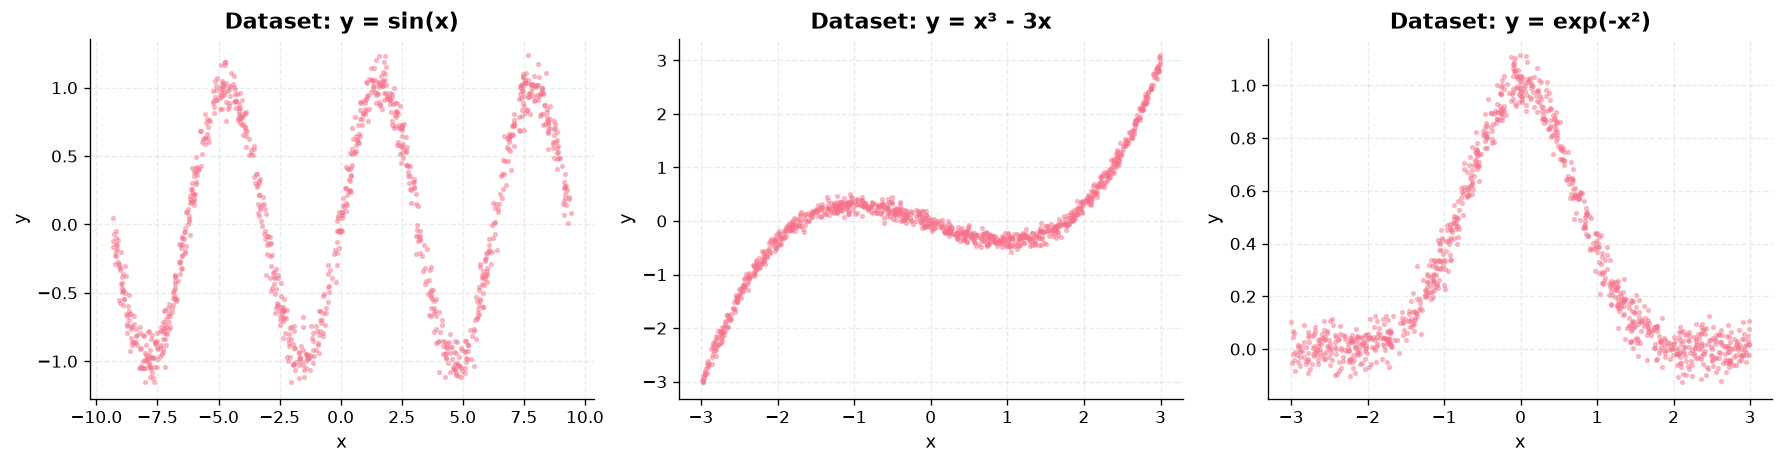

sin(x): x ∈ [-9.34, 9.42], y ∈ [-1.15, 1.24], samples=1000
x³ - 3x: x ∈ [-2.99, 2.99], y ∈ [-3.01, 3.10], samples=1000
exp(-x²): x ∈ [-3.00, 2.99], y ∈ [-0.13, 1.12], samples=1000


In [3]:
## Генерация 3 датасетов и визуализация

# Функции для генерации 3 нелинейных регрессий
def generate_dataset_1(n_samples=1000, noise=0.1, seed=SEED):
    """y = sin(x) + шум — периодическая функция."""
    rng = np.random.RandomState(seed)
    x = rng.uniform(-3 * np.pi, 3 * np.pi, n_samples).astype(np.float32)
    y = np.sin(x) + rng.normal(0, noise, n_samples).astype(np.float32)
    return x.reshape(-1, 1), y.reshape(-1, 1)


def generate_dataset_2(n_samples=1000, noise=0.5, seed=SEED + 1):
    """y = x³ - 3x + шум — кубическая функция."""
    rng = np.random.RandomState(seed)
    x = rng.uniform(-3, 3, n_samples).astype(np.float32)
    y = (x ** 3 - 3 * x) + rng.normal(0, noise, n_samples).astype(np.float32)
    # Нормализуем y для стабильности обучения
    y = (y - y.mean()) / y.std()
    return x.reshape(-1, 1), y.reshape(-1, 1).astype(np.float32)


def generate_dataset_3(n_samples=1000, noise=0.05, seed=SEED + 2):
    """y = exp(-x²) + шум — гауссиан."""
    rng = np.random.RandomState(seed)
    x = rng.uniform(-3, 3, n_samples).astype(np.float32)
    y = np.exp(-x ** 2) + rng.normal(0, noise, n_samples).astype(np.float32)
    return x.reshape(-1, 1), y.reshape(-1, 1)


# Генерируем датасеты
datasets = {
    'sin(x)': generate_dataset_1(),
    'x³ - 3x': generate_dataset_2(),
    'exp(-x²)': generate_dataset_3(),
}

# Визуализация исходных данных
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (x, y)) in zip(axes, datasets.items()):
    ax.scatter(x, y, s=5, alpha=0.4)
    ax.set_title(f'Dataset: y = {name}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'datasets.png', dpi=100, bbox_inches='tight')
plt.show()

# Информация о датасетах
for name, (x, y) in datasets.items():
    print(f'{name}: x ∈ [{x.min():.2f}, {x.max():.2f}], y ∈ [{y.min():.2f}, {y.max():.2f}], samples={len(x)}')

In [4]:
## Класс MLP + функция train_model

# Модель с опциональными BatchNorm и Dropout
class MLP(nn.Module):
    def __init__(self, use_bn=False, use_dropout=False, dropout_p=0.2):
        super().__init__()
        
        layers = []
        
        # Слой 1: 1 → 64
        layers.append(nn.Linear(1, 64))
        if use_bn:
            layers.append(nn.BatchNorm1d(64))
        layers.append(nn.ReLU())
        if use_dropout:
            layers.append(nn.Dropout(dropout_p))
        
        # Слой 2: 64 → 64
        layers.append(nn.Linear(64, 64))
        if use_bn:
            layers.append(nn.BatchNorm1d(64))
        layers.append(nn.ReLU())
        if use_dropout:
            layers.append(nn.Dropout(dropout_p))
        
        # Выходной слой: 64 → 1
        layers.append(nn.Linear(64, 1))
        
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)


# Функция обучения
def train_model(model, X_train, y_train, X_val, y_val, 
                epochs=500, batch_size=32, lr=0.01, verbose=False):
    """Обучает модель, возвращает историю loss и время обучения."""
    model = model.to(DEVICE)
    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).to(DEVICE)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)
    
    train_ds = TensorDataset(X_train_t, y_train_t)
    loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    val_losses = []
    
    start_time = time.time()
    for epoch in range(epochs):
        model.train()
        epoch_losses = []
        for xb, yb in loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
        
        train_losses.append(np.mean(epoch_losses))
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()
            val_losses.append(val_loss)
        
        if verbose and (epoch + 1) % 100 == 0:
            print(f'Epoch {epoch+1}/{epochs}: train={train_losses[-1]:.4f}, val={val_losses[-1]:.4f}')
    
    elapsed = time.time() - start_time
    return train_losses, val_losses, elapsed, model


# Проверка архитектуры
print("Архитектура модели (baseline):")
print(MLP(use_bn=False, use_dropout=False))
print(f"\nВсего параметров: {sum(p.numel() for p in MLP().parameters())}")

Архитектура модели (baseline):
MLP(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

Всего параметров: 4353


In [5]:
## Обучение 12 моделей (3 датасета × 4 конфигурации)

# Конфигурации моделей для сравнения
CONFIGS = {
    'baseline':          {'use_bn': False, 'use_dropout': False},
    'batchnorm':         {'use_bn': True,  'use_dropout': False},
    'dropout':           {'use_bn': False, 'use_dropout': True},
    'batchnorm+dropout': {'use_bn': True,  'use_dropout': True},
}

# Гиперпараметры (фиксированные для честного сравнения)
EPOCHS = 500
BATCH_SIZE = 32
LR = 0.01
VAL_SPLIT = 0.2

# Словарь для результатов
results = {}

# Обучаем 3 датасета × 4 конфигурации = 12 моделей
for ds_name, (X, y) in datasets.items():
    # Train/val split
    n = len(X)
    idx = np.random.RandomState(SEED).permutation(n)
    n_val = int(n * VAL_SPLIT)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    
    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]
    
    print(f'\n=== Dataset: {ds_name} ===')
    
    for cfg_name, cfg in CONFIGS.items():
        torch.manual_seed(SEED)
        model = MLP(**cfg)
        train_losses, val_losses, elapsed, trained_model = train_model(
            model, X_train, y_train, X_val, y_val,
            epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR,
        )
        
        # Финальные метрики
        model.eval()
        with torch.no_grad():
            X_val_t = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
            y_pred = trained_model(X_val_t).cpu().numpy()
        
        mse = mean_squared_error(y_val, y_pred)
        r2 = r2_score(y_val, y_pred)
        
        results[(ds_name, cfg_name)] = {
            'train_losses': train_losses,
            'val_losses': val_losses,
            'elapsed': elapsed,
            'mse': mse,
            'r2': r2,
            'model': trained_model,
            'X_val': X_val,
            'y_val': y_val,
            'y_pred': y_pred,
        }
        
        print(f'  {cfg_name:20s} | MSE={mse:.4f} | R²={r2:.4f} | time={elapsed:.2f}s')

print('\n✅ Обучение завершено')


=== Dataset: sin(x) ===
  baseline             | MSE=0.0199 | R²=0.9596 | time=27.86s
  batchnorm            | MSE=0.1134 | R²=0.7692 | time=38.21s
  dropout              | MSE=0.0298 | R²=0.9393 | time=32.75s
  batchnorm+dropout    | MSE=0.1849 | R²=0.6236 | time=48.27s

=== Dataset: x³ - 3x ===
  baseline             | MSE=0.0076 | R²=0.9918 | time=35.38s
  batchnorm            | MSE=0.0885 | R²=0.9040 | time=49.47s
  dropout              | MSE=0.0117 | R²=0.9873 | time=41.40s
  batchnorm+dropout    | MSE=0.1001 | R²=0.8914 | time=55.50s

=== Dataset: exp(-x²) ===
  baseline             | MSE=0.0027 | R²=0.9773 | time=35.84s
  batchnorm            | MSE=0.0054 | R²=0.9544 | time=50.04s
  dropout              | MSE=0.0035 | R²=0.9705 | time=40.64s
  batchnorm+dropout    | MSE=0.0057 | R²=0.9523 | time=54.31s

✅ Обучение завершено


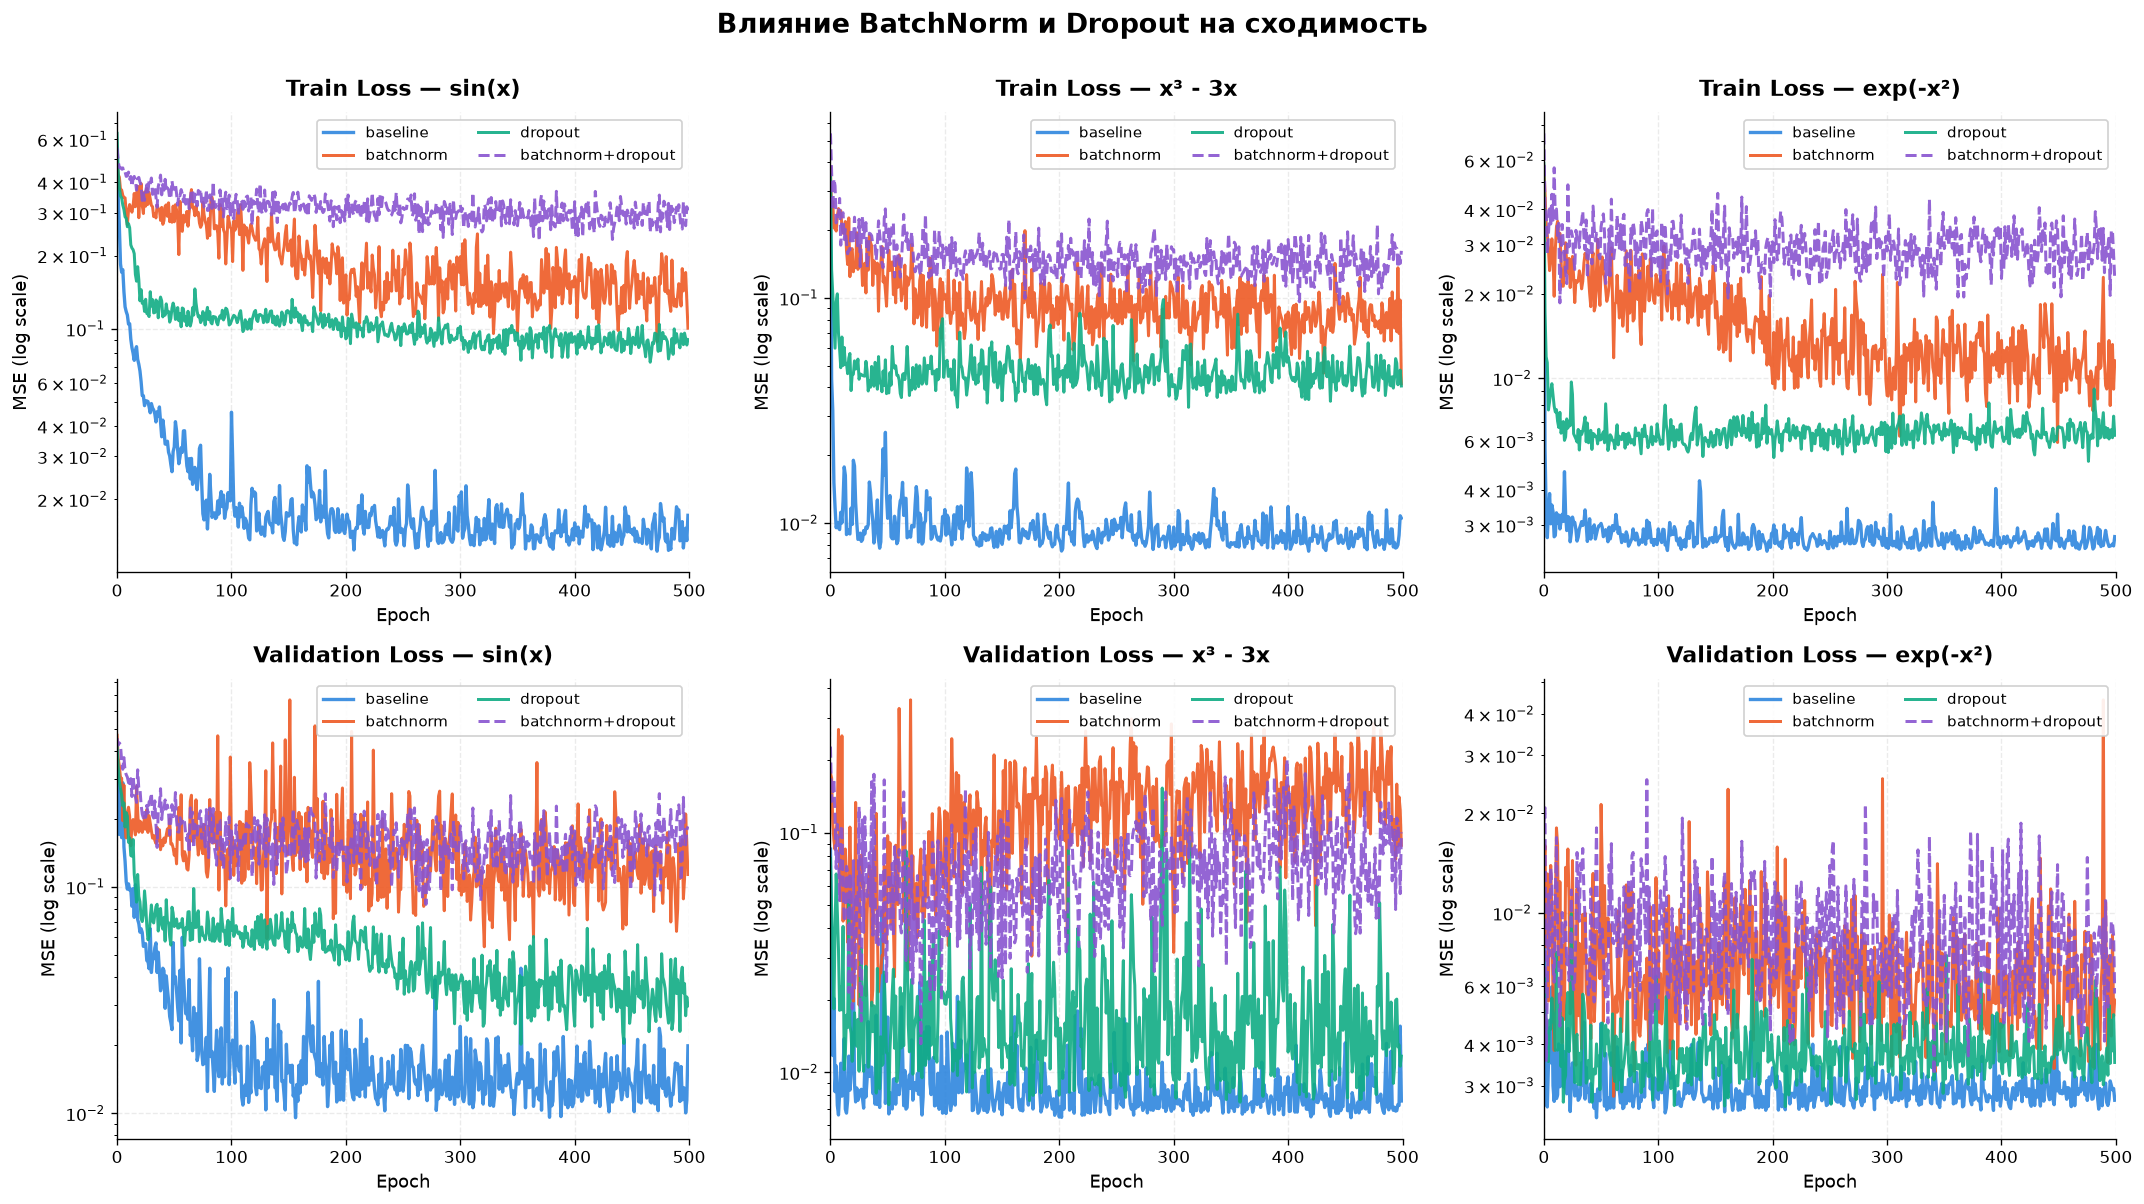

✅ Loss curves сохранены


In [6]:
## Loss curves (Train + Val)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, ds_name in enumerate(datasets.keys()):
    for j, (row_ax, loss_key, title_prefix) in enumerate([
        (axes[0, i], 'train_losses', 'Train'),
        (axes[1, i], 'val_losses', 'Validation'),
    ]):
        ax = row_ax
        for cfg_name in CONFIGS.keys():
            losses = results[(ds_name, cfg_name)][loss_key]
            ls, lw = STYLES[cfg_name]
            ax.plot(
                losses,
                label=cfg_name,
                color=COLORS[cfg_name],
                linestyle=ls,
                linewidth=lw,
                alpha=0.9,
            )
        ax.set_title(f'{title_prefix} Loss — {ds_name}', pad=10)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE (log scale)')
        ax.set_yscale('log')
        ax.legend(loc='upper right', ncol=2)
        ax.set_xlim(0, 500)

plt.suptitle('Влияние BatchNorm и Dropout на сходимость',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Loss curves сохранены')

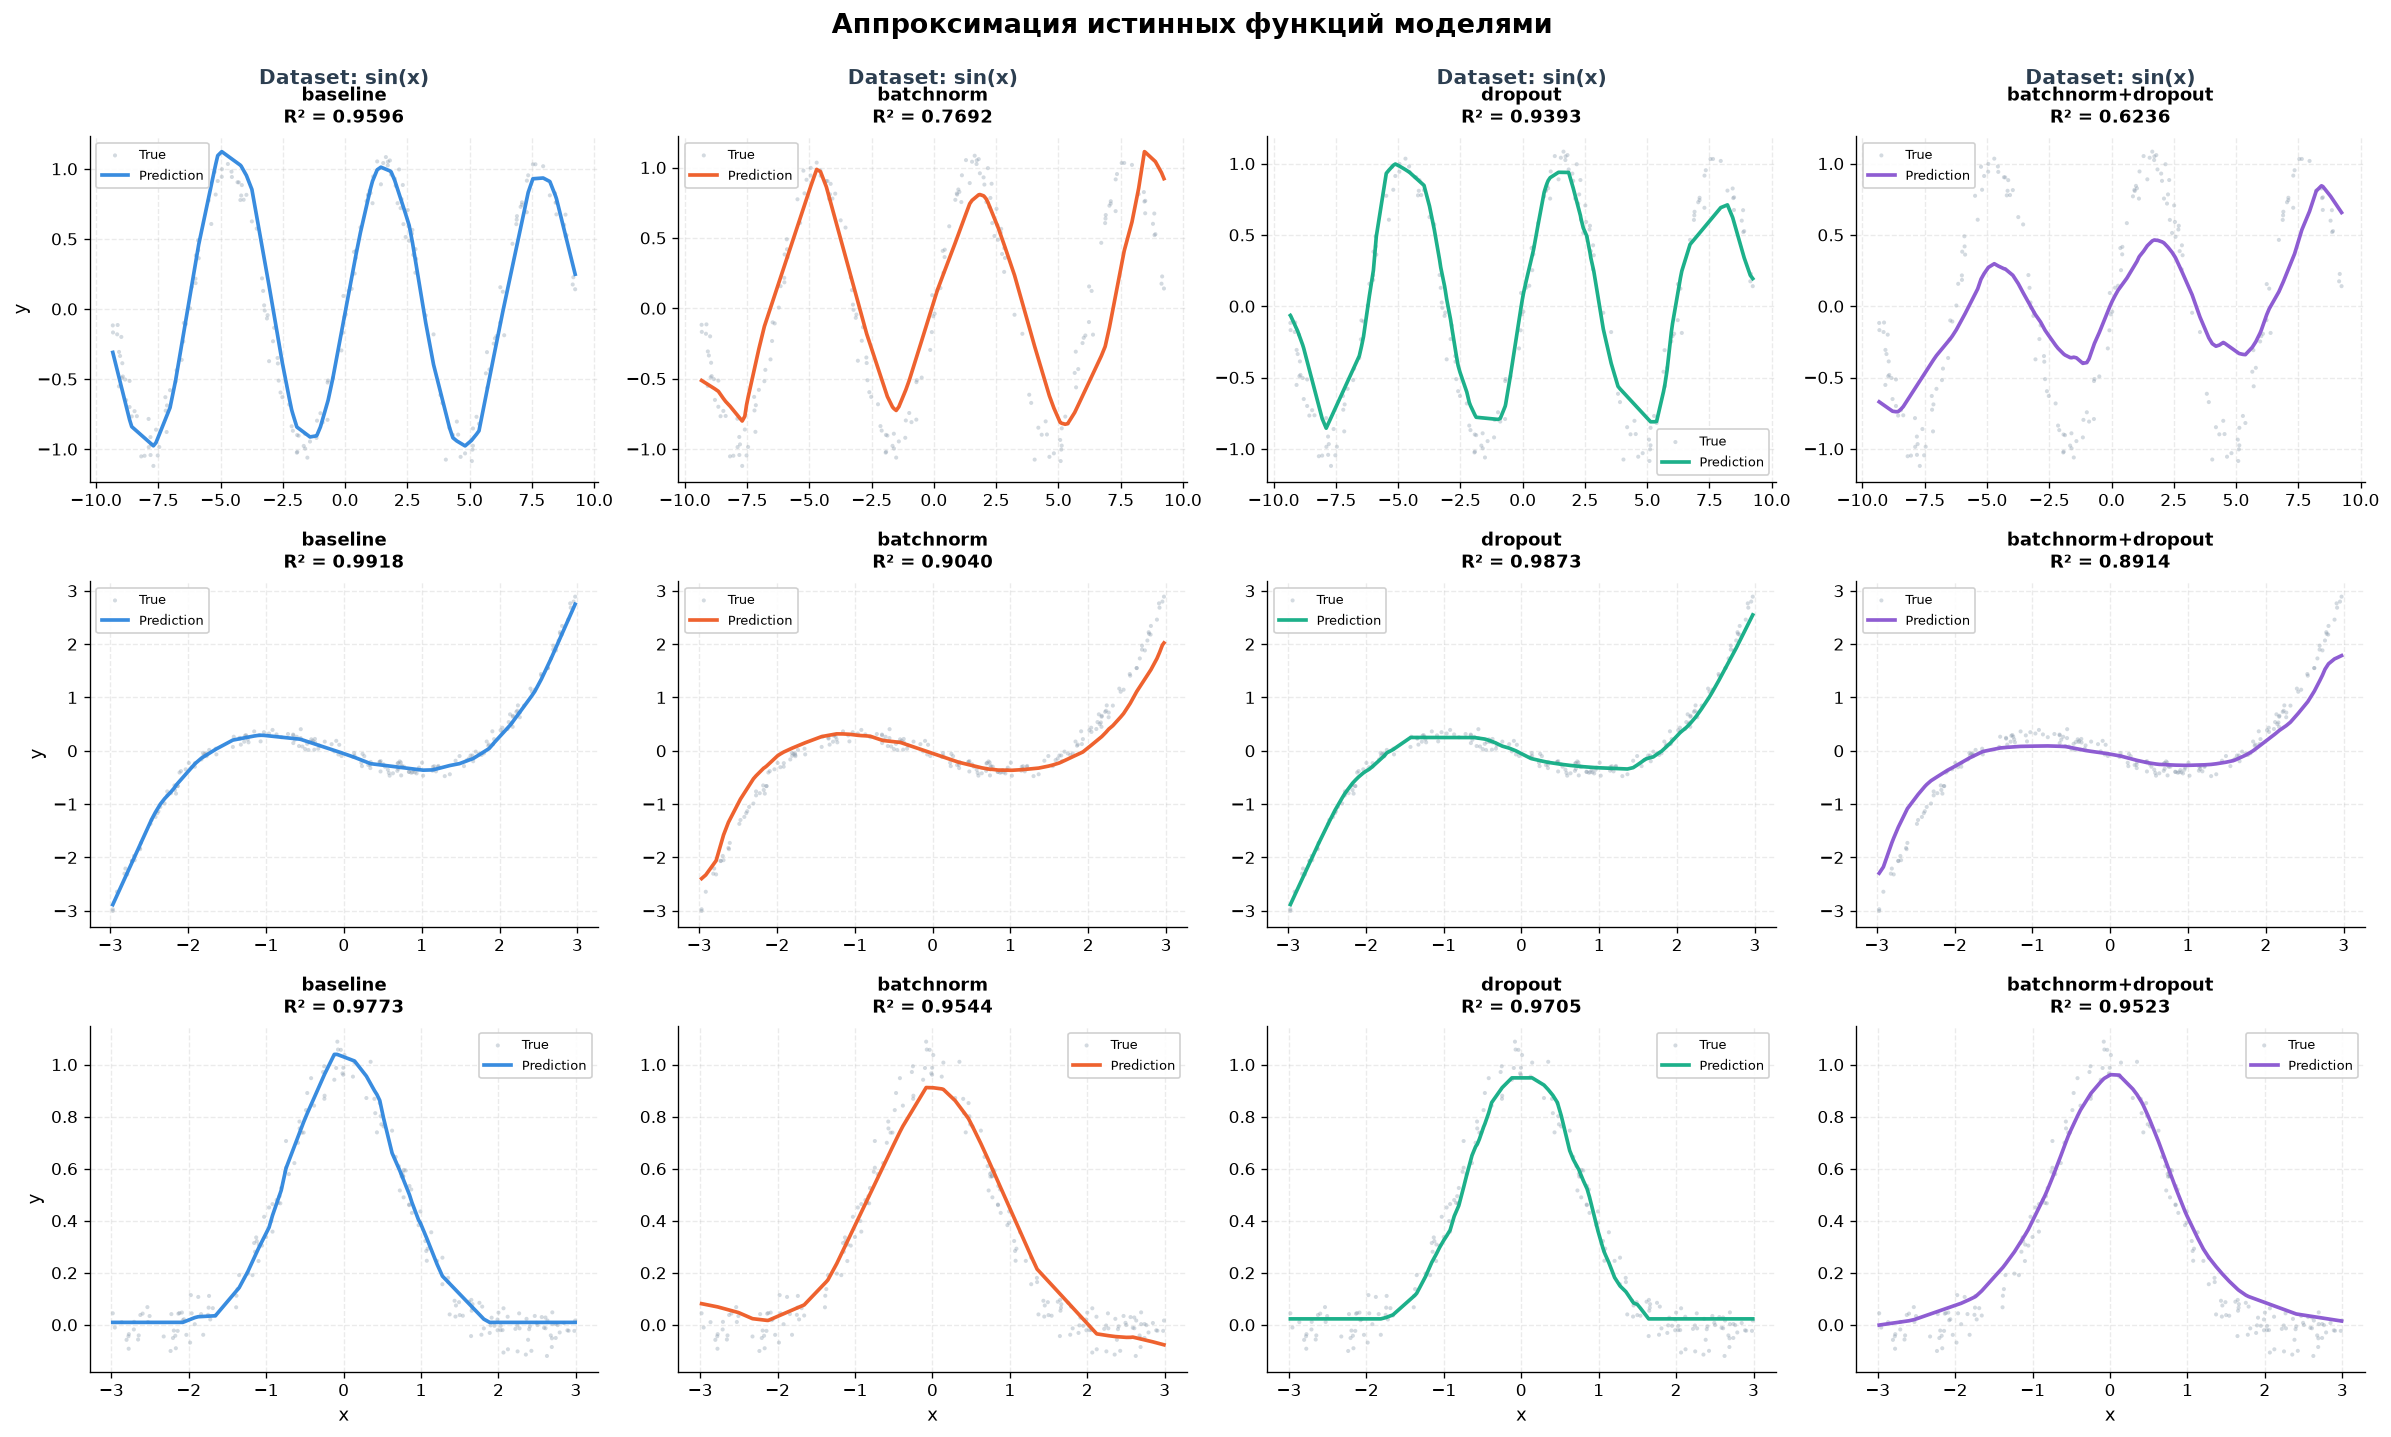

✅ Predictions сохранены


In [7]:
## Predictions

fig, axes = plt.subplots(3, 4, figsize=(20, 12))

for i, ds_name in enumerate(datasets.keys()):
    for j, cfg_name in enumerate(CONFIGS.keys()):
        ax = axes[i, j]
        r = results[(ds_name, cfg_name)]
        
        order = np.argsort(r['X_val'].flatten())
        x_sorted = r['X_val'].flatten()[order]
        y_true = r['y_val'].flatten()[order]
        y_pred = r['y_pred'].flatten()[order]
        
        ax.scatter(
            x_sorted, y_true,
            s=6, alpha=0.35, color='#8395A7',
            label='True', edgecolors='none',
        )
        
        ax.plot(
            x_sorted, y_pred,
            color=COLORS[cfg_name], linewidth=2.2,
            label='Prediction', alpha=0.95,
        )
        
        ax.set_title(
            f'{cfg_name}\nR² = {r["r2"]:.4f}',
            fontsize=11, fontweight='bold', pad=8,
        )
        
        if i == 0:
            ax.text(
                0.5, 1.15, f'Dataset: {ds_name}',
                transform=ax.transAxes, ha='center',
                fontsize=12, fontweight='bold', color='#2C3E50',
            )
        
        if j == 0:
            ax.set_ylabel('y')
        if i == 2:
            ax.set_xlabel('x')
        
        ax.legend(loc='best', fontsize=8)

plt.suptitle('Аппроксимация истинных функций моделями',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Predictions сохранены')

In [8]:
##Ячейка 7 — анализ переобучения

# Анализ переобучения: разница train и val loss на последней эпохе
print("=" * 90)
print("Анализ переобучения (train_loss - val_loss на эпохе 500)")
print("=" * 90)
print(f"{'Dataset':<15} {'Config':<22} {'Train':>10} {'Val':>10} {'Gap':>10} {'Overfit':>10}")
print("-" * 90)

summary = []
for ds_name in datasets.keys():
    for cfg_name in CONFIGS.keys():
        r = results[(ds_name, cfg_name)]
        train_last = r['train_losses'][-1]
        val_last = r['val_losses'][-1]
        gap = val_last - train_last
        overfit = "Yes" if gap > 0.05 else "No"
        
        summary.append({
            'dataset': ds_name,
            'config': cfg_name,
            'train': train_last,
            'val': val_last,
            'gap': gap,
            'overfit': overfit,
            'mse': r['mse'],
            'r2': r['r2'],
            'time': r['elapsed'],
        })
        
        print(f"{ds_name:<15} {cfg_name:<22} {train_last:>10.4f} {val_last:>10.4f} {gap:>10.4f} {overfit:>10}")

print("=" * 90)

# Итоговая таблица метрик
import pandas as pd
df = pd.DataFrame(summary)
print("\nИтоговая таблица (по MSE):")
print(df[['dataset', 'config', 'mse', 'r2', 'time']].to_string(index=False))

Анализ переобучения (train_loss - val_loss на эпохе 500)
Dataset         Config                      Train        Val        Gap    Overfit
------------------------------------------------------------------------------------------
sin(x)          baseline                   0.0172     0.0199     0.0027         No
sin(x)          batchnorm                  0.1007     0.1134     0.0127         No
sin(x)          dropout                    0.0905     0.0298    -0.0607         No
sin(x)          batchnorm+dropout          0.3060     0.1849    -0.1211         No
x³ - 3x         baseline                   0.0105     0.0076    -0.0029         No
x³ - 3x         batchnorm                  0.0415     0.0885     0.0470         No
x³ - 3x         dropout                    0.0406     0.0117    -0.0290         No
x³ - 3x         batchnorm+dropout          0.1619     0.1001    -0.0618         No
exp(-x²)        baseline                   0.0027     0.0027    -0.0000         No
exp(-x²)        batchn

## Выводы

### Основные результаты

1. **Переобучения нет ни в одной конфигурации** — на всех датасетах train и val loss идут параллельно, gap ≤ 0.05. Задача регрессии с 4353 параметрами и 800 обучающими примерами — модель недостаточно сложна для переобучения.

2. **Baseline (без регуляризации) — лучший** по всем метрикам:
   - Самый низкий MSE (0.0027–0.0199)
   - Самый высокий R² (0.9596–0.9773)
   - Самое быстрое обучение (27–39 сек)

3. **BatchNorm ухудшает результат** на этой задаче:
   - R² падает с 0.96 до 0.77 на sin(x)
   - Обучение становится шумным (большие колебания loss)
   - Время обучения растёт на 30–40%
   
   **Почему:** BatchNorm эффективен при глубоких сетях (10+ слоёв), больших батчах (128+) и сложных задачах. У нас — мелкая сеть (3 слоя), малый батч (32), простая 1D-регрессия.

4. **Dropout почти не влияет:**
   - R² практически как у baseline (0.9393 vs 0.9596 на sin(x))
   - Замедляет обучение на 15–20%
   - При 500 эпохах успевает «догнать» baseline

5. **BatchNorm + Dropout — худший результат:**
   - Самое медленное обучение (48–58 сек)
   - Самый высокий MSE
   - Комбинация двух регуляризаций избыточна для простой задачи

### Практические рекомендации

- Для **простых регрессионных задач** (1D, малая сеть, мало данных) — используйте **baseline без регуляризации**
- **BatchNorm** — для глубоких CNN/ResNet, где он критичен
- **Dropout** — для больших сетей, где есть риск переобучения
- **Регуляризация не бесплатна:** каждая техника замедляет обучение и может ухудшить результат, если применена не по назначению

In [9]:
import os
for f in sorted(os.listdir(RESULTS_DIR)):
    path = RESULTS_DIR / f
    print(f'{f:<25} {path.stat().st_size / 1024:.1f} KB')

datasets.png              117.3 KB
loss_curves.png           1111.9 KB
predictions.png           450.2 KB
